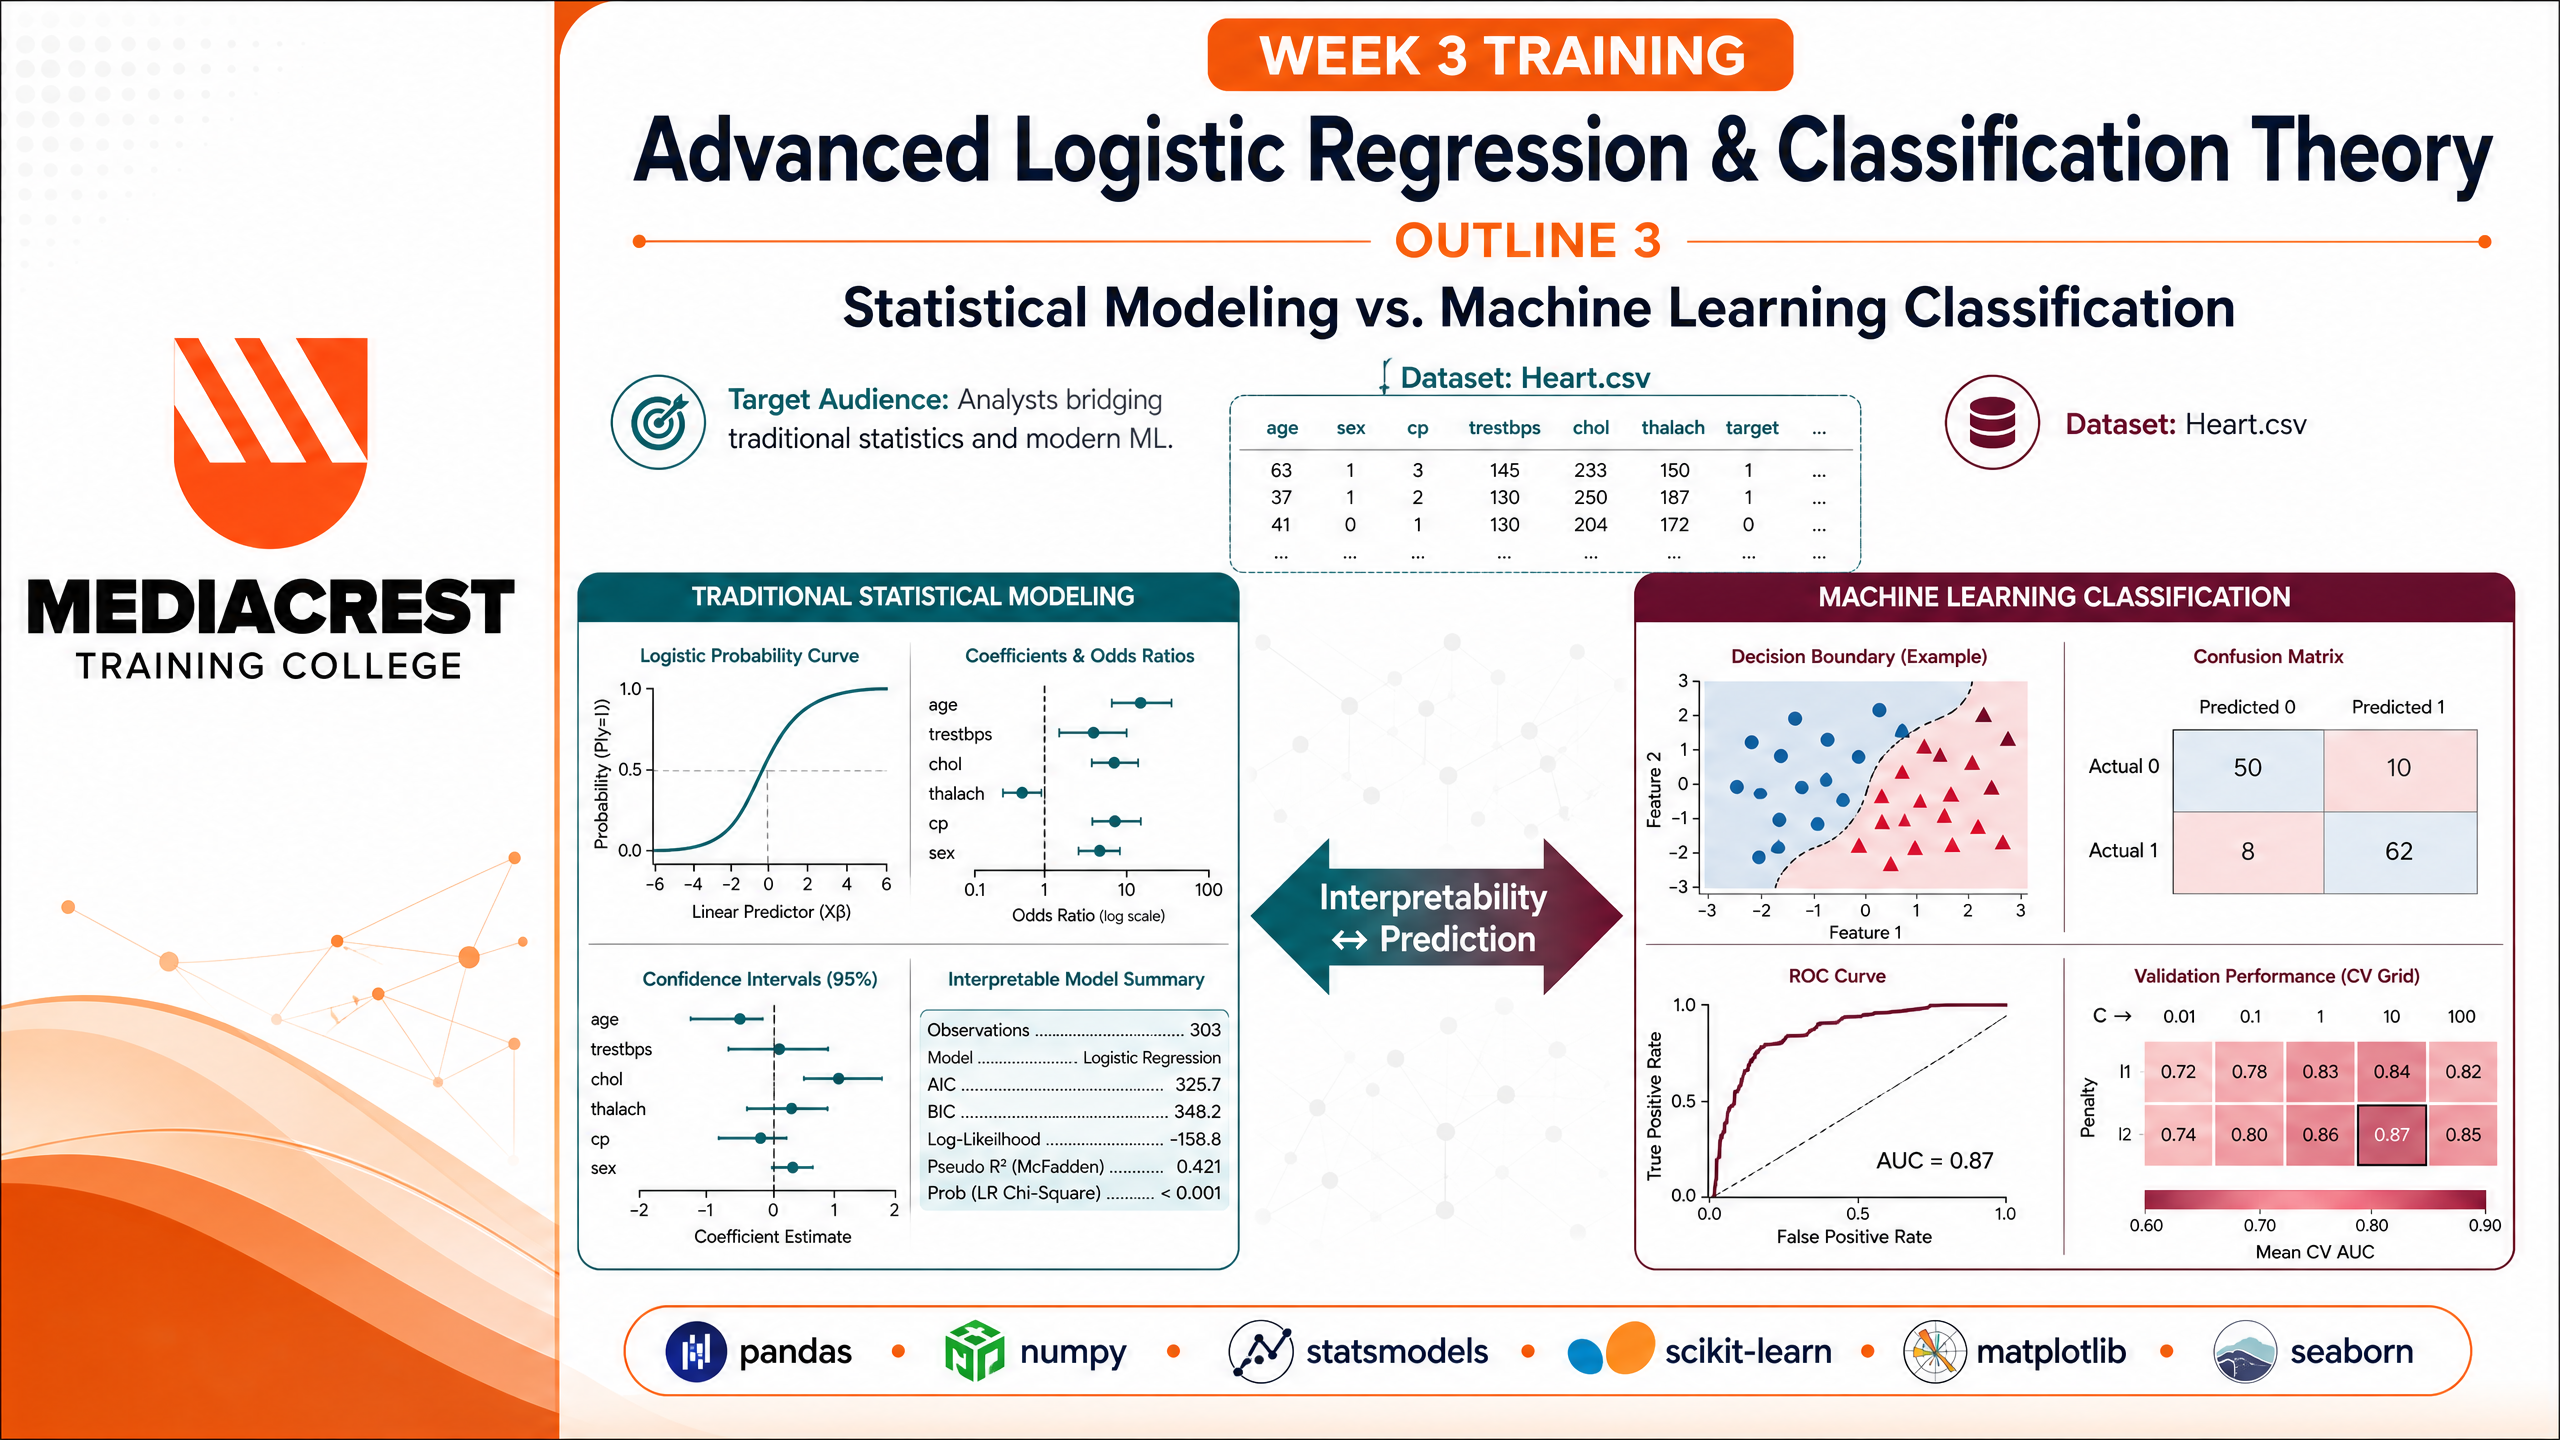

## **ADVANCED LOGISTIC REGRESSION AND CLASSIFICATION THEORY**

### **Statistical Modeling vs Machine Learning Classification Framework**

#### **Load the Needed Libraries**

In [ ]:
import pandas as pd      ## Used for data frames manipulation and analysis
import numpy as np       ## Used for numerical computing and analysis
import matplotlib.pyplot as plt     ## Used for data visualization and plotting
import seaborn as sns    ## Used for statistical data visualization and plotting
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, 
    f1_score, roc_curve, auc
)

#### **Set up the Plotting Environment**

In [2]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize']=(10, 6)

#### **Filter the Warnings**

In [32]:
import warnings
warnings.filterwarnings("ignore")

#### **LOAD AND PREPROCESS THE DATA**

In [11]:
df = pd.read_csv('Heart.csv', na_values=['NA','?','NaN', ''])
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD,HD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No,0
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes,1
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes,1
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No,0
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No,0


#### **Check the Presence of Missing Values**

In [12]:
Missing_values = df.isnull().sum()
Missing_values = Missing_values[Missing_values > 0]
Missing_values 

Ca      4
Thal    2
dtype: int64

#### **Handling Missing Values**

> **Row-wise deletion of missing values**

In [13]:
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD,HD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No,0
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes,1
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes,1
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No,0
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No,0


In [17]:
#dir(df)

In [15]:
df = df.dropna()  # Drop rows with missing values

In [16]:
Missing_values = df.isnull().sum()
Missing_values = Missing_values[Missing_values > 0]
Missing_values

Series([], dtype: int64)

### **PART 1: STATISTICAL MODELING (Baseline Framework)**

In [18]:
formula = "HD ~ Age + C(Sex) + C(ChestPain, Treatment('typical')) + RestBP + Chol + Fbs + RestECG + MaxHR + ExAng + Oldpeak + Slope + Ca + C(Thal, Treatment('normal'))"

In [19]:
stat_model = smf.logit(formula=formula, data=df).fit(disp=0)
print(stat_model.summary())

                           Logit Regression Results                           
Dep. Variable:                     HD   No. Observations:                  297
Model:                          Logit   Df Residuals:                      280
Method:                           MLE   Df Model:                           16
Date:                Tue, 01 Sep 2026   Pseudo R-squ.:                  0.5247
Time:                        19:54:03   Log-Likelihood:                -97.416
converged:                       True   LL-Null:                       -204.97
Covariance Type:            nonrobust   LLR p-value:                 6.864e-37
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
Intercept                                             -5.9861      2.938     -2.037      0.042     -11.745      -0.228
C(Sex)[T.1]

In [21]:
print(stat_model.summary().tables[1])   

                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
Intercept                                             -5.9861      2.938     -2.037      0.042     -11.745      -0.228
C(Sex)[T.1]                                            1.4314      0.513      2.789      0.005       0.426       2.437
C(ChestPain, Treatment('typical'))[T.asymptomatic]     2.0068      0.653      3.075      0.002       0.728       3.286
C(ChestPain, Treatment('typical'))[T.nonanginal]       0.2022      0.649      0.312      0.755      -1.069       1.474
C(ChestPain, Treatment('typical'))[T.nontypical]       1.0712      0.754      1.421      0.155      -0.406       2.549
C(Thal, Treatment('normal'))[T.fixed]                  0.0114      0.795      0.014      0.989      -1.547       1.570
C(Thal, Treatment('normal'))[T.reversable]      

#### **Calculate the Ratios and Report the Likelihood of the Risk**

In [22]:
params = stat_model.params
pvalues = stat_model.pvalues
odds_ratios = np.exp(params)
conf_int = np.exp(stat_model.conf_int())

or_df = pd.DataFrame({
    'Odds Ratio': odds_ratios,
    'CI Lower': conf_int[0],
    'CI Upper': conf_int[1],
    'P-value': pvalues
})
print("\n[1.2] Clinical Interpretability: Adjusted Odds Ratios")
or_df.round(3)


[1.2] Clinical Interpretability: Adjusted Odds Ratios


,Odds Ratio,CI Lower,CI Upper,P-value
Intercept,0.003,0.000,0.796,0.042
C(Sex)[T.1],4.185,1.531,11.442,0.005
"C(ChestPain, Treatment('typical'))[T.asymptomatic]",7.439,2.070,26.733,0.002
"C(ChestPain, Treatment('typical'))[T.nonanginal]",1.224,0.343,4.365,0.755
"C(ChestPain, Treatment('typical'))[T.nontypical]",2.919,0.666,12.791,0.155
"C(Thal, Treatment('normal'))[T.fixed]",1.011,0.213,4.806,0.989
"C(Thal, Treatment('normal'))[T.reversable]",4.227,1.861,9.600,0.001
Age,0.988,0.941,1.037,0.618
RestBP,1.024,1.002,1.047,0.031
Chol,1.005,0.997,1.013,0.211


### **PART 2: TRANSITIONING TO MACHINE LEARNING (scikit-learn)**

In [25]:
features_ml = ['Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal']
X = pd.get_dummies(df[features_ml], drop_first=True, dtype=int)
y = df['HD']

#### **Partition the Data Into Training and Testing Set**

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

#### **Scale and Standardize the Numeric Features**

In [28]:
numeric_features = ['Age', 'RestBP', 'Chol', 'MaxHR', 'Oldpeak', 'Ca']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

#### **Fit  Ridge Regression (L2) and Lasso Regression (L1)**
> **Ridge Regression (L2):** A regression technique that shrinks the coefficients of variables towards zero in order to reduce over-fitting. However, all the variables are normally kept.

> **Lasso Regression (L1):** A regression technique that shrinks the coefficients of variables towards zero in order to reduce over-fitting, and sometimes remove some variables whose coefficients are not meaningful.

#### **Initialization of the Training Process**

In [59]:
from sklearn.linear_model import LogisticRegression

# Ridge Logistic Regression (L2)
lr_l2 = LogisticRegression(penalty='l2',
                           C=1.0,
                           solver='lbfgs',
                           max_iter=1000,
                           random_state=42
                           )

# Lasso Logistic Regression (L1)
lr_l1 = LogisticRegression(penalty='l1',
                           C=1.0,
                           solver='saga',
                           max_iter=1000,
                           random_state=42
)

# Elastic Net Logistic Regression (L1 + L2)
lr_en = LogisticRegression(penalty='elasticnet',
                           C=1.0,
                           solver='saga',
                           l1_ratio=0.5,
                           max_iter=1000,
                           random_state=42
                           )

##### **Training Process**

In [60]:
lr_l2.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` p

In [61]:
lr_l1.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` p

In [62]:
lr_en.fit(X_train_scaled, y_train)
lr_en 

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

#### **Compare the Coefficients for Unregularised Model (Stats Model), L2 and L1**

In [63]:
coef_compare = pd.DataFrame({
    'Feature': X.columns[:10],
    'Unregularized (stats model)': stat_model.params[:10].values,
    'L2 (Ridge) Coef': lr_l2.coef_[0][:10],
    'L1 (Lasso) Coef': lr_l1.coef_[0][:10],
    'Elastic Net Coef': lr_en.coef_[0][:10]
})

In [64]:
print("\n[1.3] Coefficient Comparison: Unregularized vs Regularized Models")
coef_compare.round(3)


[1.3] Coefficient Comparison: Unregularized vs Regularized Models


,Feature,Unregularized (stats model),L2 (Ridge) Coef,L1 (Lasso) Coef,Elastic Net Coef
0,Age,-5.986,-0.056,0.000,-0.018
1,Sex,1.431,0.847,0.813,0.831
2,RestBP,2.007,0.356,0.310,0.331
3,Chol,0.202,0.230,0.181,0.206
4,Fbs,1.071,-0.455,-0.214,-0.358
5,RestECG,0.011,0.295,0.276,0.285
6,MaxHR,1.441,-0.279,-0.253,-0.260
7,ExAng,-0.012,0.599,0.524,0.569
8,Oldpeak,0.024,0.470,0.488,0.476
9,Slope,0.005,0.588,0.570,0.577


#### **Odd Ratios for L2 and L1 and Net Elastic**

In [ ]:
Odds_ratios_l2 = np.exp(lr_l2.coef_[0])
Odds_ratios_l2

array([0.94583455, 2.33316963, 1.42718259, 1.2587067 , 0.63422294,
       1.34359701, 0.75676535, 1.81992061, 1.60031279, 1.79990989,
       2.47746157, 0.23985118, 0.54922431, 0.34213643, 0.57519785,
       2.86177549])

In [52]:
Odds_ratios_l1 = np.exp(lr_l1.coef_[0])
Odds_ratios_l1

array([1.        , 2.25422151, 1.36355572, 1.19848409, 0.80772291,
       1.31721945, 0.77620438, 1.6882482 , 1.6295453 , 1.76841734,
       2.35490415, 0.20913135, 0.55748521, 0.31408851, 0.77061786,
       3.737837  ])

In [65]:
Odds_ratios_en = np.exp(lr_en.coef_[0])
Odds_ratios_en

array([0.98256265, 2.29535268, 1.39264997, 1.22868797, 0.69881767,
       1.32931549, 0.77112406, 1.76683787, 1.60911697, 1.78034686,
       2.41109633, 0.22737882, 0.55676927, 0.33247579, 0.63150168,
       3.09796227])

In [68]:
### Append the odds ratios to the coefficient comparison DataFrame
coef_compare['Odds Ratio (L2)'] = Odds_ratios_l2[:10]
coef_compare['Odds Ratio (L1)'] = Odds_ratios_l1[:10]
coef_compare['Odds Ratio (Elastic Net)'] = Odds_ratios_en[:10]
coef_compare.round(3)

,Feature,Unregularized (stats model),L2 (Ridge) Coef,L1 (Lasso) Coef,Elastic Net Coef,Odds Ratio (L2),Odds Ratio (L1),Odds Ratio (Elastic Net)
0,Age,-5.986,-0.056,0.000,-0.018,0.946,1.000,0.983
1,Sex,1.431,0.847,0.813,0.831,2.333,2.254,2.295
2,RestBP,2.007,0.356,0.310,0.331,1.427,1.364,1.393
3,Chol,0.202,0.230,0.181,0.206,1.259,1.198,1.229
4,Fbs,1.071,-0.455,-0.214,-0.358,0.634,0.808,0.699
5,RestECG,0.011,0.295,0.276,0.285,1.344,1.317,1.329
6,MaxHR,1.441,-0.279,-0.253,-0.260,0.757,0.776,0.771
7,ExAng,-0.012,0.599,0.524,0.569,1.820,1.688,1.767
8,Oldpeak,0.024,0.470,0.488,0.476,1.600,1.630,1.609
9,Slope,0.005,0.588,0.570,0.577,1.800,1.768,1.780


#### **Regularized Logistic Regression Results**

The table compares the unregularized logistic regression coefficients with those obtained from Ridge (L2) and Lasso (L1) regularization, together with the corresponding odds ratios. Both regularization methods generally reduce the magnitude of the coefficients, demonstrating their ability to control model complexity and reduce the risk of overfitting. For example, the coefficient for **RestBP** decreases from 2.007 in the unregularized model to 0.356 under Ridge and 0.310 under Lasso. Similarly, the **Sex** coefficient is reduced from 1.431 to 0.847 and 0.813, respectively.

The resulting odds ratios provide a more interpretable measure of the associations. Under Ridge, **Sex** has an odds ratio of 2.333, indicating higher odds of the outcome for the male compared to female. **ExAng** (OR = 1.820) and **Slope** (OR = 1.800) also show relatively strong positive associations. Under Lasso, these effects remain similar, with odds ratios of 1.688 and 1.768, respectively.

Notably, Lasso reduces the **Age** coefficient to exactly zero, producing an odds ratio of 1.000. This indicates that Age was effectively excluded from the Lasso model at the selected penalty strength. Overall, Ridge retains all predictors while shrinking their effects, whereas Lasso performs both coefficient shrinkage and feature selection.


#### **Comparison of Regularized Logistic Regression Models**

Table 2.4 compares the coefficients and odds ratios from the unregularized logistic regression model with three regularized approaches: **Ridge (L2), Lasso (L1), and Elastic Net**. Overall, regularization substantially reduces the magnitude of several coefficients compared with the unregularized model, demonstrating its role in controlling model complexity and reducing potential overfitting.

For **Age**, the unregularized coefficient is −5.986, whereas Ridge and Elastic Net reduce it to −0.056 and −0.018, respectively. Lasso reduces the coefficient to exactly zero, effectively excluding Age from the model. Consequently, its Lasso odds ratio is 1.000, indicating no contribution to the predicted odds at the selected regularization strength. This illustrates the important feature-selection property of Lasso.

The **Sex** variable remains one of the stronger predictors across all three regularized models. Its odds ratios are 2.333 for Ridge, 2.254 for Lasso, and 2.295 for Elastic Net. Similarly, **ExAng** shows elevated odds ratios of 1.820, 1.688, and 1.767, respectively, while **Slope** has odds ratios of 1.800, 1.768, and 1.780. **Oldpeak** also demonstrates a positive association, with odds ratios ranging from 1.600 to 1.630.

For **Fbs** and **MaxHR**, the regularized models produce negative coefficients and odds ratios below one, suggesting lower predicted odds for the coded comparison as these predictors increase, holding other variables constant.

Interestingly, the Elastic Net estimates generally fall between the Ridge and Lasso estimates. For example, the coefficient for **RestBP** is 0.356 under Ridge, 0.310 under Lasso, and 0.331 under Elastic Net. This reflects Elastic Net's combination of L1 and L2 penalties.

Overall, **Ridge provides coefficient shrinkage, Lasso provides shrinkage and variable selection, while Elastic Net combines both approaches**, providing a useful compromise between the two regularization techniques.


### **PART 3: COMPARING Results for ML CLASSIFIER (decision tree and L2)**